# Importing & Cleaning the Data

Dataset "Materials and their Mechanical Properties" 

from: https://www.kaggle.com/datasets/purushottamnawale/materials

The dataset was obtained from the Autodesk Material Library. Due to missing values, I`m only utilized seven of these columns for my ML model.

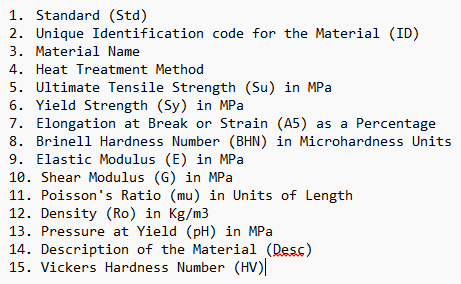

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\KPI\Intelectual_data_analyse\materials_and_mechanical_properties\Data.csv")
pd.set_option('display.max.rows', 15)
df

,Std,ID,Material,Heat treatment,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,Desc,HV
0,ANSI,D8894772B88F495093C43AF905AB6373,Steel SAE 1015,as-rolled,421,314,39.0,126.0,207000,79000,0.30,7860,NaN,NaN,NaN
1,ANSI,05982AC66F064F9EBC709E7A4164613A,Steel SAE 1015,normalized,424,324,37.0,121.0,207000,79000,0.30,7860,NaN,NaN,NaN
2,ANSI,356D6E63FF9A49A3AB23BF66BAC85DC3,Steel SAE 1015,annealed,386,284,37.0,111.0,207000,79000,0.30,7860,NaN,NaN,NaN
3,ANSI,1C758F8714AC4E0D9BD8D8AE1625AECD,Steel SAE 1020,as-rolled,448,331,36.0,143.0,207000,79000,0.30,7860,NaN,NaN,NaN
4,ANSI,DCE10036FC1946FC8C9108D598D116AD,Steel SAE 1020,normalized,441,346,35.8,131.0,207000,79000,0.30,7860,550.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547,JIS,512A80EC21EA416BA2725B38BA8096EF,Nodular cast iron,NaN,600,370,NaN,NaN,169000,70000,0.20,7160,480.0,Nodular cast iron,210.0
1548,JIS,38526441BA8741CA979DBF870D0B8A9B,Nodular cast iron,NaN,700,420,NaN,NaN,169000,70000,0.20,7160,560.0,Nodular cast iron,230.0
1549,JIS,CAC03D7EB1AA45E68EFF92A2EF4C3D9B,Nodular cast iron,NaN,800,480,NaN,NaN,169000,70000,0.20,7160,600.0,Nodular cast iron,240.0
1550,JIS,45C82A36EC644F8BB6170A99ED819B62,Malleable cast iron,NaN,400,180,4.0,NaN,160000,64000,0.27,7160,300.0,Malleable cast iron,220.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             1552 non-null   str    
 1   ID              1552 non-null   str    
 2   Material        1552 non-null   str    
 3   Heat treatment  802 non-null    str    
 4   Su              1552 non-null   int64  
 5   Sy              1552 non-null   str    
 6   A5              1346 non-null   float64
 7   Bhn             463 non-null    float64
 8   E               1552 non-null   int64  
 9   G               1552 non-null   int64  
 10  mu              1552 non-null   float64
 11  Ro              1552 non-null   int64  
 12  pH              193 non-null    float64
 13  Desc            981 non-null    str    
 14  HV              165 non-null    float64
dtypes: float64(5), int64(4), str(6)
memory usage: 299.1 KB


In [4]:
df.isnull().sum()

Std                  0
ID                   0
Material             0
Heat treatment     750
Su                   0
Sy                   0
A5                 206
Bhn               1089
E                    0
G                    0
mu                   0
Ro                   0
pH                1359
Desc               571
HV                1387
dtype: int64

In [5]:
df.nunique()

Std                  8
ID                1552
Material          1225
Heat treatment      44
Su                 309
Sy                 291
A5                  98
Bhn                143
E                   43
G                   33
mu                  11
Ro                  35
pH                  53
Desc                83
HV                  48
dtype: int64

In [6]:
# converting "Sy" from 'str' to 'int' data type
# df['Sy'] = pd.to_numeric(df['Sy'], errors='coerce').astype('Int64')
# The issue is that there are values like "125 max"; accordingly, it is sufficient to replace "max" with ""
df['Sy'] = df['Sy'].str.replace(' max', '').astype(int)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             1552 non-null   str    
 1   ID              1552 non-null   str    
 2   Material        1552 non-null   str    
 3   Heat treatment  802 non-null    str    
 4   Su              1552 non-null   int64  
 5   Sy              1552 non-null   int64  
 6   A5              1346 non-null   float64
 7   Bhn             463 non-null    float64
 8   E               1552 non-null   int64  
 9   G               1552 non-null   int64  
 10  mu              1552 non-null   float64
 11  Ro              1552 non-null   int64  
 12  pH              193 non-null    float64
 13  Desc            981 non-null    str    
 14  HV              165 non-null    float64
dtypes: float64(5), int64(5), str(5)
memory usage: 294.5 KB


In [8]:
df['Material'] = df[['Std', 'Material', 'Heat treatment']].fillna('').agg(' '.join, axis=1).str.strip().str.replace(r'\s+', ' ', regex=True)

In [9]:
Clean_Table = df.drop(['Std', 'Heat treatment', 'A5', 'Bhn', 'pH', 'Desc', 'HV', 'ID'],axis = 1)
Clean_Table.head(5)

,Material,Su,Sy,E,G,mu,Ro
0,ANSI Steel SAE 1015 as-rolled,421,314,207000,79000,0.3,7860
1,ANSI Steel SAE 1015 normalized,424,324,207000,79000,0.3,7860
2,ANSI Steel SAE 1015 annealed,386,284,207000,79000,0.3,7860
3,ANSI Steel SAE 1020 as-rolled,448,331,207000,79000,0.3,7860
4,ANSI Steel SAE 1020 normalized,441,346,207000,79000,0.3,7860


In [10]:
df.corr(numeric_only=True)

,Su,Sy,A5,Bhn,E,G,mu,Ro,pH,HV
Su,1.000000,0.957244,-0.265907,0.944583,0.594348,0.254508,-0.239663,0.407995,0.628327,0.571687
Sy,0.957244,1.000000,-0.390863,0.893887,0.472434,0.179293,-0.190256,0.273860,0.640122,0.616172
A5,-0.265907,-0.390863,1.000000,-0.103373,0.051015,0.180311,0.080796,0.369102,-0.144015,-0.275909
Bhn,0.944583,0.893887,-0.103373,1.000000,0.689378,0.217086,-0.496645,0.696002,0.877276,NaN
E,0.594348,0.472434,0.051015,0.689378,1.000000,0.279431,-0.446692,0.716853,0.482121,0.365177
G,0.254508,0.179293,0.180311,0.217086,0.279431,1.000000,-0.108699,0.222848,0.462504,0.341028
mu,-0.239663,-0.190256,0.080796,-0.496645,-0.446692,-0.108699,1.000000,-0.400175,0.413740,0.409708
Ro,0.407995,0.273860,0.369102,0.696002,0.716853,0.222848,-0.400175,1.000000,0.549353,0.547990
pH,0.628327,0.640122,-0.144015,0.877276,0.482121,0.462504,0.413740,0.549353,1.000000,0.982863
HV,0.571687,0.616172,-0.275909,NaN,0.365177,0.341028,0.409708,0.547990,0.982863,1.000000


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

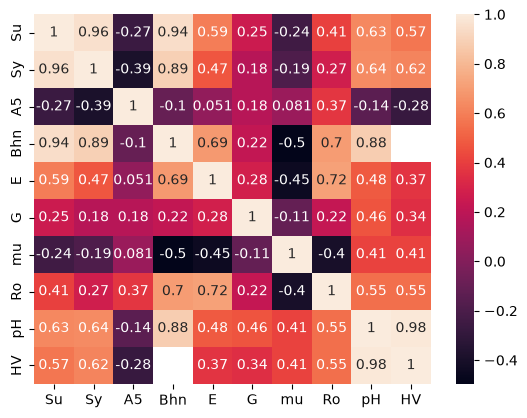

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

plt.rcParams['figure.figsize'] = (25, 8)

plt.show()

# Train Test Split

Quote from the dataset authors: "We added an 8th column in the dataset called 'Use' which contains binary values (Yes/No). This column is called Label. The Label contains Yes or No values." As I understand it, we will use the values from this column to train my ML model. Accordingly, we should define specific conditions for the 'Use' column—such as whether the material should be used based on its mechanical properties.

In [13]:
df['Use'] = (
    (df['Su'].between(292, 683)) &
    (df['Sy'].between(212, 494)) &
    (df['E'].between(196650, 217350)) &
    (df['G'].between(47400, 110600)) &
    (df['mu'].between(0.225, 0.375)) &
    (df['Ro'].between(6288, 9432))
).map({True: 'Yes', False: 'No'})

In [14]:
Clean_Table.insert(1, 'Use', df.pop('Use'))
Clean_Table.head(5)

,Material,Use,Su,Sy,E,G,mu,Ro
0,ANSI Steel SAE 1015 as-rolled,Yes,421,314,207000,79000,0.3,7860
1,ANSI Steel SAE 1015 normalized,Yes,424,324,207000,79000,0.3,7860
2,ANSI Steel SAE 1015 annealed,Yes,386,284,207000,79000,0.3,7860
3,ANSI Steel SAE 1020 as-rolled,Yes,448,331,207000,79000,0.3,7860
4,ANSI Steel SAE 1020 normalized,Yes,441,346,207000,79000,0.3,7860


In [15]:
# Clean_Table.to_csv(r"D:\KPI\Intelectual_data_analyse\Pr_2\material.csv", index=False)

In [16]:
# X = df.drop(['Std', 'Material', 'Heat treatment', 'A5', 'Bhn', 'pH', 'Desc', 'HV', 'ID'],axis = 1)
X = Clean_Table[['Su', 'Sy', 'E', 'G', 'mu', 'Ro']]
X.head(5)

,Su,Sy,E,G,mu,Ro
0,421,314,207000,79000,0.3,7860
1,424,324,207000,79000,0.3,7860
2,386,284,207000,79000,0.3,7860
3,448,331,207000,79000,0.3,7860
4,441,346,207000,79000,0.3,7860


In [17]:
y = Clean_Table['Use']

In [18]:
print(type(X), type(y))
print(X.shape, y.shape)

<class 'pandas.DataFrame'> <class 'pandas.Series'>
(1552, 6) (1552,)


In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Decision Tree

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import set_config
set_config(display="text")

In [21]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

In [22]:
# model = DecisionTreeClassifier()

In [23]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, random_state=42)

In [24]:
y_pred = model.predict(X_test)

# Model Evaluation

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00       225
         Yes       1.00      1.00      1.00        86

    accuracy                           1.00       311
   macro avg       1.00      1.00      1.00       311
weighted avg       1.00      1.00      1.00       311



In [27]:
print(confusion_matrix(y_test, y_pred))

[[225   0]
 [  0  86]]


# Visualization

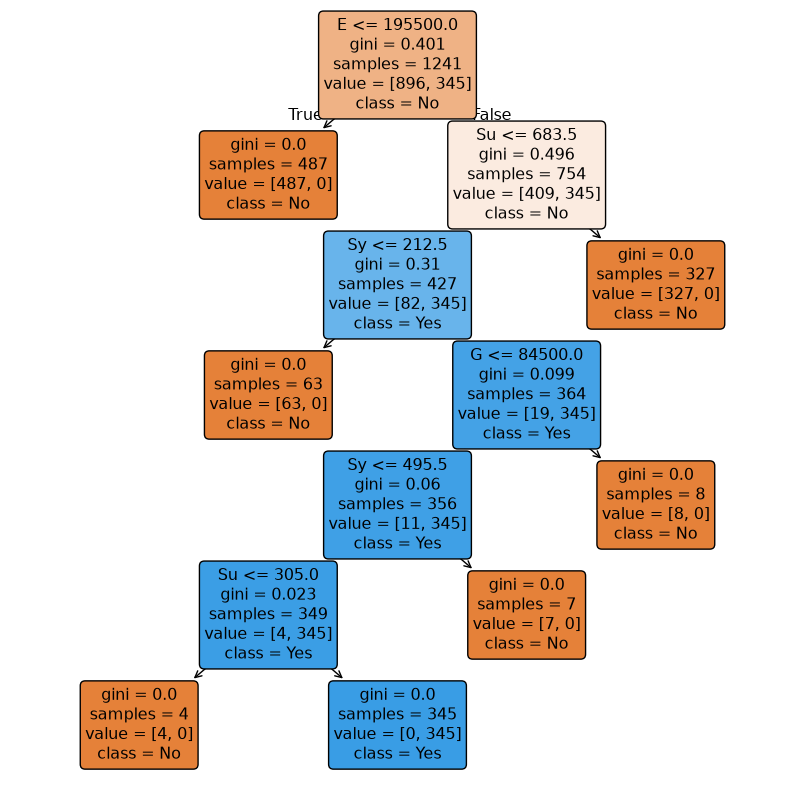

In [28]:
plt.figure(figsize = (10, 10))
plot_tree(model, feature_names = X.columns, class_names = ['No', 'Yes'], filled = True, rounded=True)
plt.show()

In [29]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 6,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [30]:
model.feature_importances_

array([0.50119802, 0.22060607, 0.24869594, 0.02949996, 0.        ,
       0.        ])

In [31]:
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': 100*model.feature_importances_}).sort_values(by='Importance', ascending=False)
importance_df_display = importance_df.copy()
importance_df_display['Importance'] = importance_df_display['Importance'].apply(lambda x: f"{x:.2f}%")
print(importance_df_display)

  Feature Importance
0      Su     50.12%
2       E     24.87%
1      Sy     22.06%
3       G      2.95%
4      mu      0.00%
5      Ro      0.00%


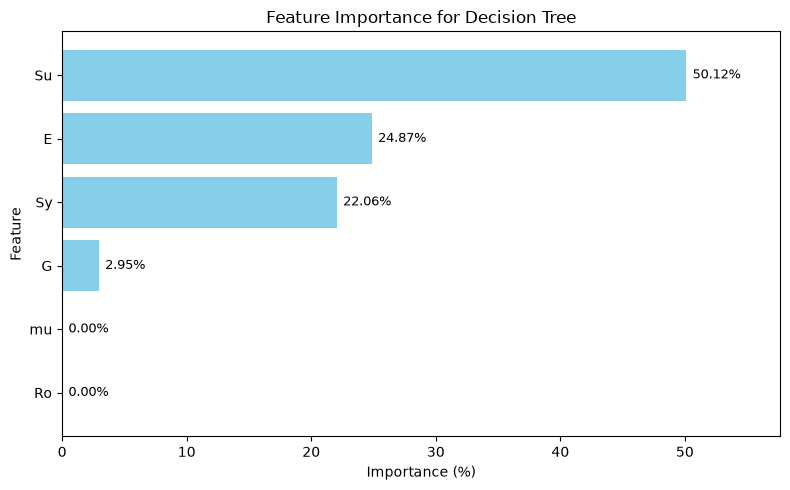

In [32]:
plt.figure(figsize=(8, 5))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,                             
        bar.get_y() + bar.get_height() / 2,      
        f'{width:.2f}%',                         
        va='center', ha='left', fontsize=9
    )
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.title('Feature Importance for Decision Tree')
plt.xlim(0, max(importance_df['Importance']) * 1.15)
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

# K Nearest Neighbors (KNN model)

Machine learning algorithms that rely on distances (such as KNN) are sensitive to feature scaling.

StandardScaler scales all features to a common range:

- mean = 0, standard deviation = 1

(so that no single variable "dominates" simply due to its scale)

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(display="text")

In [34]:
scaler = StandardScaler()

In [35]:
scaler.fit(X_train)

StandardScaler()

In [36]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)
# Test data must simulate "new," unseen data,
# so we use the mean and standard deviation from the training data only.

In [37]:
# KNN model
knn = KNeighborsClassifier(n_neighbors=3)

In [38]:
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [39]:
pred = knn.predict(scaled_X_test)

# Model Evaluation

In [40]:
print(confusion_matrix(y_test,pred))

[[221   4]
 [  1  85]]


In [41]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

          No       1.00      0.98      0.99       225
         Yes       0.96      0.99      0.97        86

    accuracy                           0.98       311
   macro avg       0.98      0.99      0.98       311
weighted avg       0.98      0.98      0.98       311



In [42]:
print('accuracy: ' f"{accuracy_score(y_test,pred):.2%}")

accuracy: 98.39%


# Choosing a K Value

In [43]:
error_rate = []

for i in range(1,30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_X_train,y_train)
    pred_i = knn.predict(scaled_X_test)
    error_rate.append(np.mean(pred_i != y_test))

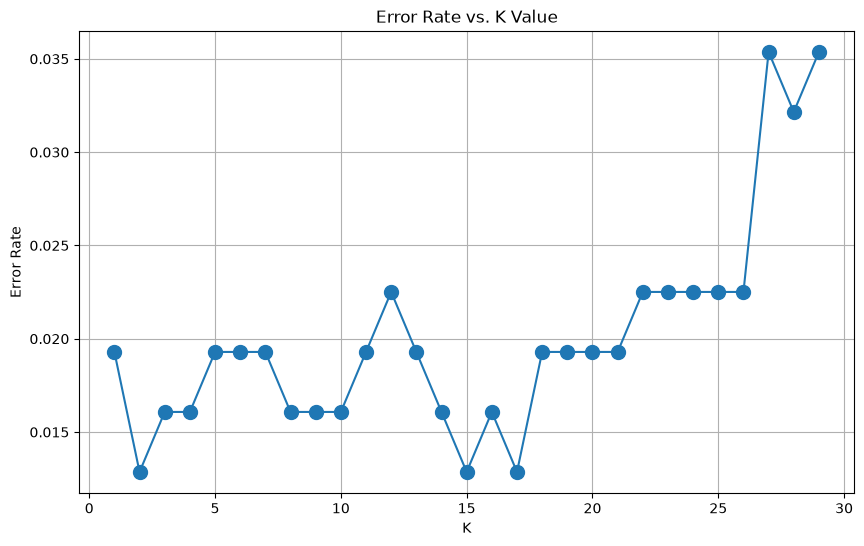

In [44]:
plt.figure(figsize=(10,6))
plt.plot(range(1,30), error_rate, marker='o', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()

In [45]:
knn = KNeighborsClassifier(n_neighbors=15)

knn.fit(scaled_X_train,y_train)
pred = knn.predict(scaled_X_test)

print(confusion_matrix(y_test,pred))
print()
print(classification_report(y_test,pred))
print()
print('accuracy: ' f"{accuracy_score(y_test,pred):.2%}")

[[221   4]
 [  0  86]]

              precision    recall  f1-score   support

          No       1.00      0.98      0.99       225
         Yes       0.96      1.00      0.98        86

    accuracy                           0.99       311
   macro avg       0.98      0.99      0.98       311
weighted avg       0.99      0.99      0.99       311


accuracy: 98.71%


In [46]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 15,
 'p': 2,
 'weights': 'uniform'}

**Найважливіші параметри (коротко)**

n_neighbors = 15 — кількість найближчих сусідів, які враховуються при класифікації

metric = 'minkowski' — метрика для обчислення відстаней

p = 2 — параметр для Minkowski: p=2 → евклідова відстань, p=1 → мангеттенська

weights ∈ {'uniform', 'distance'} — спосіб врахування сусідів: усі однаково чи ближчі мають більшу вагу, default=’uniform’

# Support Vector Machine (SVM)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV

from sklearn import set_config
set_config(display='text')

In [48]:
# Standardize the Variables
# SVM is very sensitive to feature scaling. StandardScaler() is the most common choice for SVM

scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

## SVM model

Реалізація базується на бібліотеці libsvm

**Найважливіші параметри `SVC`:**
* **`C=1.0`** — коефіцієнт регуляризації. Чим більше `C`, тим менше регуляризації → модель намагається правильно класифікувати кожну точку (ризик переобучення). Чим менше `C`, тим більше регуляризації → спрощена межа, можливі помилки (краще узагальнення).
* **`kernel='rbf'`** — ядро, яке використовується для побудови межі.
    * `'linear'` — лінійна межа; швидко, коли дані майже лінійно роздільні.
    * `'rbf'` (радіальне базисне) — універсальне, добре працює в більшості випадків.
* **`gamma='scale'`** — впливає на “радіус впливу” однієї точки.
    * Маленьке `gamma` → широка межа (гладка, але може недонавчатись).
    * Велике `gamma` → межа «підганяється» під точки (ризик переобучення).
    * `'scale'` — стандартне значення, зазвичай добре працює.

In [49]:
model = SVC(C=1.0, gamma = 1.0, kernel = 'rbf')

In [50]:
model.fit(scaled_X_train,y_train)

SVC(gamma=1.0)

In [51]:
y_pred = model.predict(scaled_X_test)

# Model Evaluation

In [52]:
print(confusion_matrix(y_test, y_pred))

[[220   5]
 [  1  85]]


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      0.98      0.99       225
         Yes       0.94      0.99      0.97        86

    accuracy                           0.98       311
   macro avg       0.97      0.98      0.98       311
weighted avg       0.98      0.98      0.98       311



# Gridsearch

In [54]:
param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel': ['rbf']}

In [55]:
grid = GridSearchCV(SVC(), param_grid, cv=5,refit=True)

# grid = GridSearchCV(
#     estimator=model,     # яку модель навчаємо (наприклад, SVC())
#     param_grid=params,   # словник з гіперпараметрами для перебору
#     cv=5                  # кількість фолдів у крос-валідації
# )

**`GridSearchCV(SVC(), param_grid, refit=True)`**
* перебирає всі комбінації параметрів з `param_grid`;
* автоматично проводить крос-валідацію для кожного набору параметрів;
* обирає найкращу модель;
* `refit=True` → після пошуку ще раз навчає SVC на всіх даних з найкращими параметрами.

In [56]:
grid.fit(scaled_X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']})

In [57]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'rbf'}

In [58]:
grid.best_estimator_

SVC(C=100, gamma=1)

In [59]:
grid_predictions = grid.predict(scaled_X_test)

In [60]:
print(confusion_matrix(y_test,grid_predictions))

[[223   2]
 [  0  86]]


In [61]:
print(classification_report(y_test,grid_predictions))
print('accuracy: ' f"{accuracy_score(y_test,grid_predictions):.2%}")

              precision    recall  f1-score   support

          No       1.00      0.99      1.00       225
         Yes       0.98      1.00      0.99        86

    accuracy                           0.99       311
   macro avg       0.99      1.00      0.99       311
weighted avg       0.99      0.99      0.99       311

accuracy: 99.36%


**Example of GridSearchCV() for KNN**

In [62]:
from sklearn.neighbors import KNeighborsClassifier
knn_params = {'n_neighbors': range(1, 30)}
knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn.fit(scaled_X_train, y_train)
print("Best KNN:", knn.best_params_, "Score:", knn.score(scaled_X_test, y_test))

Best KNN: {'n_neighbors': 6} Score: 0.9807073954983923


# Random Forest (RF)

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(display="text")
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [64]:
# Train a random forest classifier with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [65]:
# Predict the usage of a new material
new_material = np.array([440, 325, 207000, 79000, 0.3, 7860]).reshape(1, -1)
new_use = rf.predict(new_material)
print("Predicted usage of the new material:", new_use)

Predicted usage of the new material: ['Yes']


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**Just for the sake of interest, let’s assign a quality rating to each material and then determine the rating for any newly introduced material.**

In [66]:
def get_rating(row):
    if (438.3 <= row['Su'] <= 535.7 and
        318.6 <= row['Sy'] <= 389.4 and
        204930 <= row['E'] <= 209070 and
        71100 <= row['G'] <= 86900 and
        0.285 <= row['mu'] <= 0.315 and
            7467 <= row['Ro'] <= 8253):
        return 5
    elif (389.6 <= row['Su'] <= 584.4 and
          283.2 <= row['Sy'] <= 424.8 and
          202860 <= row['E'] <= 211140 and
          63200 <= row['G'] <= 94800 and
          0.27 <= row['mu'] <= 0.33 and
          7074 <= row['Ro'] <= 8646):
        return 4
    elif (340.9 <= row['Su'] <= 633.1 and
          247.8 <= row['Sy'] <= 460.2 and
          200790 <= row['E'] <= 213210 and
          55300 <= row['G'] <= 102700 and
          0.255 <= row['mu'] <= 0.345 and
          6681 <= row['Ro'] <= 9039):
        return 3
    elif (292.2 <= row['Su'] <= 681.8 and
          212.4 <= row['Sy'] <= 495.6 and
          198720 <= row['E'] <= 215280 and
          47400 <= row['G'] <= 110600 and
          0.24 <= row['mu'] <= 0.36 and
          6288 <= row['Ro'] <= 9432):
        return 2
    else:
        return 1

In [67]:
Clean_Table_for_rating = df.drop(['Std', 'Heat treatment', 'A5', 'Bhn', 'pH', 'Desc', 'HV', 'ID'],axis = 1)
# Calculate the rating for each row
Clean_Table_for_rating['rating'] = Clean_Table_for_rating.apply(get_rating, axis=1)
Clean_Table_for_rating.head(5)

,Material,Su,Sy,E,G,mu,Ro,rating
0,ANSI Steel SAE 1015 as-rolled,421,314,207000,79000,0.3,7860,4
1,ANSI Steel SAE 1015 normalized,424,324,207000,79000,0.3,7860,4
2,ANSI Steel SAE 1015 annealed,386,284,207000,79000,0.3,7860,3
3,ANSI Steel SAE 1020 as-rolled,448,331,207000,79000,0.3,7860,5
4,ANSI Steel SAE 1020 normalized,441,346,207000,79000,0.3,7860,5


In [68]:
# Clean_Table_for_rating.to_csv(r"D:\KPI\Intelectual_data_analyse\Pr_2\material_rating.csv", index=False)

In [69]:
# Separate the features and label columns
X_rating = Clean_Table_for_rating.iloc[:, 1:-1].values
y_rating = Clean_Table_for_rating.iloc[:, -1].values

# Train Test Split

In [79]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X_rating, y_rating, test_size=0.20, random_state=42, stratify=y_rating)

In [77]:
# Train a random forest classifier with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred = rf.predict(X_test)

# Model Evaluation

In [80]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('accuracy: ' f"{accuracy_score(y_test, y_pred):.2%}")

[[228   0   0   0   0]
 [  1  31   0   0   0]
 [  0   0  24   1   0]
 [  0   0   0  16   0]
 [  0   0   0   0  10]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       228
           2       1.00      0.97      0.98        32
           3       1.00      0.96      0.98        25
           4       0.94      1.00      0.97        16
           5       1.00      1.00      1.00        10

    accuracy                           0.99       311
   macro avg       0.99      0.99      0.99       311
weighted avg       0.99      0.99      0.99       311

accuracy: 99.36%


**Predicting the rating of a new material**

In [81]:
new_material_test = np.array([440, 325, 207000, 79000, 0.3, 7860]).reshape(1, -1)
new_rating = rf.predict(new_material_test)
print("Predicted rating of the new material:", new_rating)

Predicted rating of the new material: [5]


In [82]:
material_name = input("Enter name of your material: ")
while True:
    try:
        Su = int(input("Enter value for Ultimate Tensile Strenght (0-3000) MPa: "))
        break
    except ValueError:
        print("Error. Try again")

while True:
    try:
        Sy = int(input("Enter value for Yield Strenght (0-3000) MPa: "))
        break
    except ValueError:
        print("Error. Try again")

while True:
    try:
        E = int(input("Enter value for Elastic Modulus (50000-300000) MPa: "))
        break
    except ValueError:
        print("Error. Try again")

while True:
    try:
        G = int(input("Enter value for Shear Module (10000-90000) MPa: "))
        break
    except ValueError:
        print("Error. Try again")

while True:
    try:
        mu = float(input("Enter value for Poisson`s Ratio (0.20-0.50): "))
        break
    except ValueError:
        print("Error. Try again")

while True:
    try:
        Ro = int(input("Enter value for Density (1500-9999) Kg/m^3: "))
        break
    except ValueError:
        print("Error. Try again")


new_material = np.array([Su, Sy, E, G, mu, Ro]).reshape(1, -1)
new_rating = rf.predict(new_material)
print("Predicted rating of the new material:", new_rating)

Enter name of your material:  Magic Stone
Enter value for Ultimate Tensile Strenght (0-3000) MPa:  440
Enter value for Yield Strenght (0-3000) MPa:  325
Enter value for Elastic Modulus (50000-300000) MPa:  207000
Enter value for Shear Module (10000-90000) MPa:  79000
Enter value for Poisson`s Ratio (0.20-0.50):  0.3
Enter value for Density (1500-9999) Kg/m^3:  7860


Predicted rating of the new material: [5]


# Visualisation

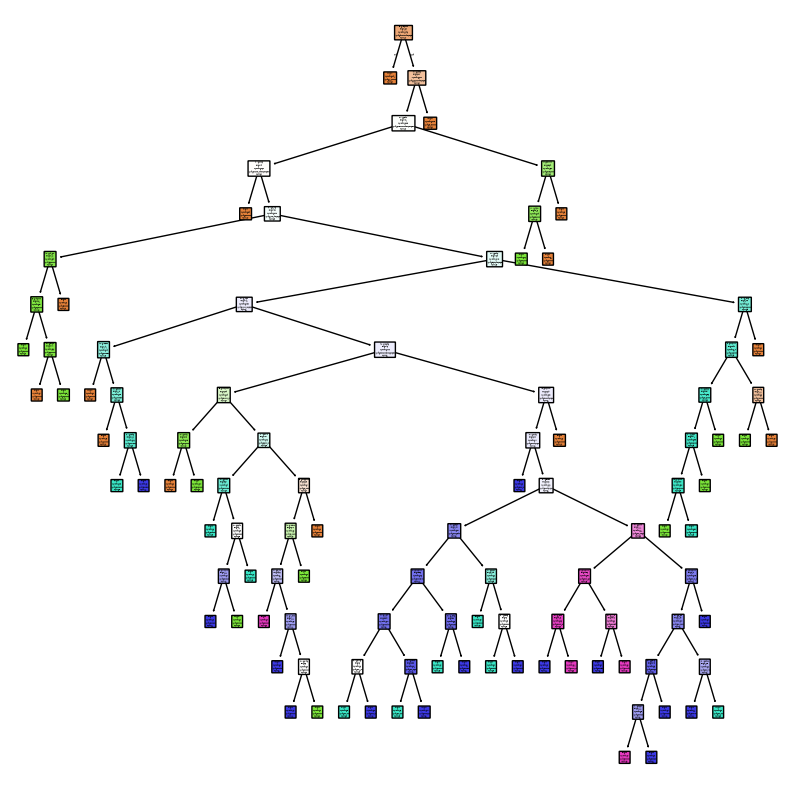

In [83]:
plt.figure(figsize = (10, 10))
plot_tree(rf.estimators_[0], feature_names = X.columns, class_names = ['1', '2', '3', '4', '5'], filled = True, rounded=True)
plt.show()

# Model comparison

**Evaluation for Decision Tree**

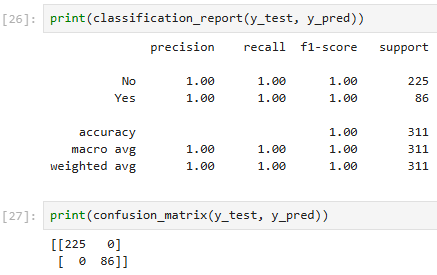

**Evaluation for KNN with K value = 15**

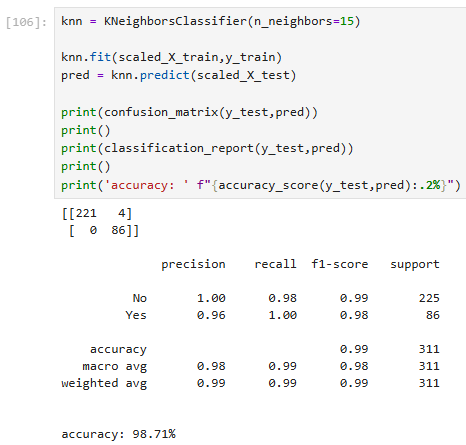

**Evaluation for SVM with Gridsearch**

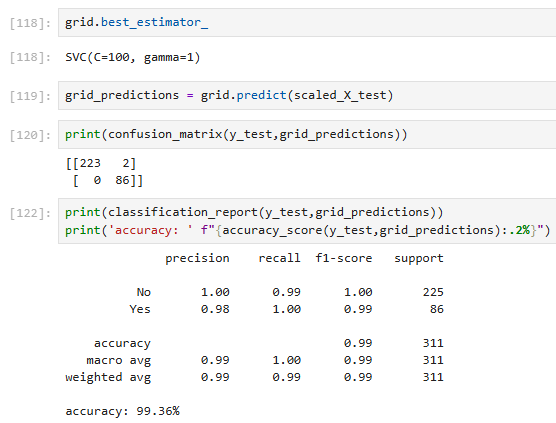

**Evaluation for RF**

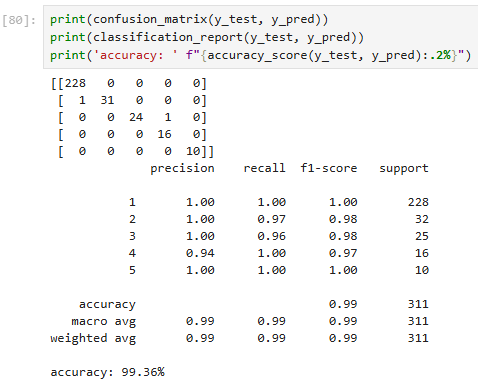

**In other words, it is evident that using a Decision Tree is sufficient for our purposes. Additionally, SVM and RF yielded identical results for this dataset.**